# Chapter 18 -- Entropy Features

Price series convey information about supply and demand. This chapter asks: how much
information does a price series actually carry, and can we measure it directly from
real data? We build four things:

1. **Plug-in and Lempel-Ziv entropy estimators** (Snippets 18.1-18.4) -- ways to
   estimate Shannon's entropy rate from a single observed sequence, without knowing
   the true underlying probabilities.
2. **Encoding schemes** (Sec 18.5) -- the glue that turns continuous real returns into
   the discrete strings those estimators actually operate on.
3. **A market-microstructure adverse-selection feature** (Sec 18.8.4) -- a real
   workflow combining quantization + rolling entropy + an empirical CDF into a single
   per-bar feature, built on Ch19's real order-flow data.
4. **Portfolio concentration** (Sec 18.8.3) -- Meucci's entropy-inspired measure of how
   concentrated a portfolio's risk is across a covariance matrix's principal
   components, run against Chapter 16's real 6-commodity covariance matrix and HRP/IVP
   allocation vectors.

Three sections of the book (18.2 Shannon entropy/MI, 18.6 the Gaussian entropy
benchmark, 18.7 the generalized mean) remain conceptual scaffolding rather than
pipeline-producing formulas for this project -- covered here as discussion, not code.
Per this project's standing rule, they're flagged as revisitable (not permanently
skipped) once a later chapter makes them directly usable -- exactly what happened with
portfolio concentration once Chapter 16 supplied a real multi-asset covariance matrix.


## Setup

Per this project's convention, notebooks use a hardcoded `AFML_ROOT` (Jupyter's
working directory isn't reliably the notebook's own folder) -- **edit this one line
for your machine**.

In [1]:
AFML_ROOT = r'C:\ws\AFML'  # <-- EDIT THIS for your machine

import os, sys
sys.path.insert(0, AFML_ROOT)
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch18', 'entropy_features'))
INPUT_DATA = os.path.join(AFML_ROOT, 'input_data')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from encoding_schemes import binary_encode, quantile_encode, sigma_encode
from entropy_estimators import pmf1, plugIn, lempelZiv_lib, matchLength, konto
from adverse_selection import order_flow_imbalance, adverse_selection_feature

## Plain-English: how do the estimators work?

- **plugIn (Snippet 18.1)**: count how often each length-`w` "word" appears in the
  observed message, treat that empirical frequency as the true probability, and apply
  Shannon's formula. Simple, but needs enough data for the counts to be meaningful.
- **konto (Snippet 18.4, Kontoyiannis)**: for each position, find the longest stretch
  that's already appeared earlier in the message. Repetitive (predictable) messages
  produce long matches -> low entropy. Unpredictable messages produce short matches ->
  high entropy. This is the estimator most of this chapter's real-data results use.

## Small worked example (matches the module's own hand-traced tests)

In [2]:
h, pmf = plugIn('0011', 1)
print('plugIn(\'0011\', 1) =', h, ' pmf =', pmf)
print('(standard binary entropy of a Bernoulli(1/3) rv -- exact match)')

lib = lempelZiv_lib('101010')
print('lempelZiv_lib(\'101010\') =', lib)

length, sub = matchLength('0011001100', 4, 4)
print('matchLength(...) =', (length, sub))

out = konto('10'*20)
print('konto(repetitive) h =', out['h'])
rng = np.random.RandomState(0)
random_msg = ''.join(str(x) for x in rng.randint(0,2,40))
out_r = konto(random_msg)
print('konto(random)     h =', out_r['h'], ' (higher, as expected)')

plugIn('0011', 1) = 0.9182958340544896  pmf = {'0': 0.6666666666666666, '1': 0.3333333333333333}
(standard binary entropy of a Bernoulli(1/3) rv -- exact match)
lempelZiv_lib('101010') = ['1', '0', '10']
matchLength(...) = (5, '0011')
konto(repetitive) h = 0.35926125508423923
konto(random)     h = 0.9041031222017182  (higher, as expected)


## Part A -- real BTC/TUSD data: rebuild the canonical dollar bars

Same $10,000 threshold, same methodology as every other chapter (Ch02 onward).

In [3]:
DOLLAR_BAR_THRESHOLD = 10000.0

trades_path = os.path.join(INPUT_DATA, 'BTCTUSD-trades-2026-03.csv')
raw = pd.read_csv(trades_path, header=None,
                   names=['TradeID', 'Price', 'Volume', 'QuoteVolume',
                          'Timestamp', 'IsBuyerMaker', 'IsBestMatch'])
raw['Date'] = pd.to_datetime(raw['Timestamp'], unit='us')
raw['Label'] = raw['IsBuyerMaker'].apply(lambda x: -1 if x else 1)
trades = raw[['Date', 'Price', 'Volume', 'Label']].copy()
print(f"Loaded {len(trades)} real trades")

cumm_dollar, bar_id, bar_ids = 0.0, 0, []
for price, volume in zip(trades['Price'], trades['Volume']):
    cumm_dollar += price * volume
    bar_ids.append(bar_id)
    if cumm_dollar >= DOLLAR_BAR_THRESHOLD:
        bar_id += 1
        cumm_dollar = 0.0
trades['bar_id'] = bar_ids

n_complete_bars = trades['bar_id'].max()
trades = trades[trades['bar_id'] < n_complete_bars].copy()
print(f"{n_complete_bars} complete dollar bars ({len(trades)} trades used)")

bars = trades.groupby('bar_id').agg(
    Open=('Price', 'first'), High=('Price', 'max'), Low=('Price', 'min'), Close=('Price', 'last'),
    Volume=('Volume', 'sum'), n_trades=('Price', 'size'),
)
dollar_per_trade = trades['Price'] * trades['Volume']
bars['DollarVolume'] = dollar_per_trade.groupby(trades['bar_id']).sum()
bars['BuyVolume'] = trades[trades['Label'] == 1].groupby('bar_id')['Volume'].sum().reindex(bars.index).fillna(0)
bars['SellVolume'] = trades[trades['Label'] == -1].groupby('bar_id')['Volume'].sum().reindex(bars.index).fillna(0)
bars.head()

Loaded 9205 real trades
249 complete dollar bars (9195 trades used)


,Open,High,Low,Close,Volume,n_trades,DollarVolume,BuyVolume,SellVolume
bar_id,,,,,,,,,
0,67068.88,67170.26,66213.21,66916.48,0.15369,36,10254.024887,0.05765,0.09604
1,67122.05,67659.71,67122.05,67659.71,0.16118,28,10868.174348,0.11527,0.04591
2,68000.00,68227.62,67529.54,67637.30,0.16442,42,11146.362463,0.06847,0.09595
3,67600.01,67656.64,66932.86,66932.86,0.14852,47,10005.500279,0.03600,0.11252
4,66893.34,67353.11,66384.47,66498.04,0.15169,51,10128.652506,0.05723,0.09446


## Part A continued -- encoding schemes + entropy estimators on real returns

Three encodings, side by side, on the same 248 real bar-to-bar returns.

In [4]:
returns = bars['Close'].pct_change().dropna()
print(f"{len(returns)} real bar-to-bar returns")

encodings = {
    'binary': binary_encode(returns),
    'quantile (n=5)': quantile_encode(returns.values, n_letters=5),
    'sigma (default step=std/4)': sigma_encode(returns.values),
}

results = []
for name, encoded in encodings.items():
    alphabet = sorted(set(encoded))
    h1, _ = plugIn(encoded, 1)
    konto_input = encoded if len(encoded) % 2 == 0 else encoded[:-1]
    out = konto(konto_input)
    results.append({
        'encoding': name, 'alphabet_size': len(alphabet),
        'plugIn_h_w1': h1, 'theoretical_max': np.log2(len(alphabet)),
        'konto_h': out['h'], 'konto_r': out['r'],
    })

results_df = pd.DataFrame(results).set_index('encoding')
results_df

248 real bar-to-bar returns


,alphabet_size,plugIn_h_w1,theoretical_max,konto_h,konto_r
encoding,,,,,
binary,2,0.999733,1.000000,0.864423,0.887744
quantile (n=5),5,2.321738,2.321928,1.692823,0.787179
sigma (default step=std/4),23,3.781852,4.523562,2.409312,0.697102


**Real finding:** binary-encoded entropy (0.9997 bits) sits almost exactly at the
theoretical max of 1 bit -- BTC's real up/down sequence reads as close to
indistinguishable from a coin flip. This corroborates Ch13's `phi_hat~1.03`
random-walk finding via a completely independent method (information theory rather
than an O-U mean-reversion fit).

**Caveat** (matches the book's own Sec 18.5.2 warning): quantile encoding's entropy
reading (2.322 bits) sits almost exactly at `log2(5)=2.3219`, the theoretical MAX for
a 5-letter alphabet -- a property of quantile encoding itself (it forces near-uniform
bin counts by construction), not independent evidence of high information content.
Binary and sigma encoding, which don't force uniformity, are the more trustworthy
readings here.

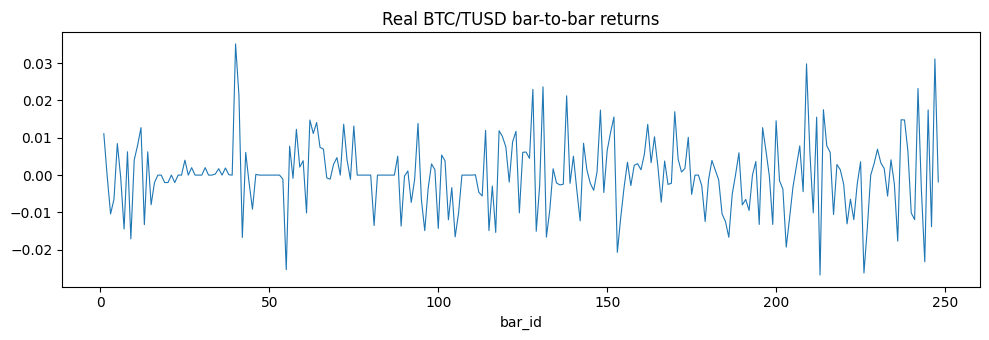

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(returns.index, returns.values, linewidth=0.8)
ax.set_title('Real BTC/TUSD bar-to-bar returns')
ax.set_xlabel('bar_id')
plt.tight_layout()
plt.show()

## Part B -- 18.8.4 adverse-selection workflow on real order flow

Order-flow imbalance per bar (Ch19's real `BuyVolume`/`SellVolume`) -> quantile-encode
-> rolling Kontoyiannis entropy -> empirical CDF. The rolling-window mechanics here are
this project's own judgment call (the book gives six prose steps but no algorithm for
turning one entropy estimate into a time series) -- documented in
`adverse_selection.py`'s own docstring, not silently resolved.

220 real per-bar feature values (249 bars, roll_window=30 -> 220 output points)
mean=0.5023, std=0.2893, range=[0.0045, 1.0000]


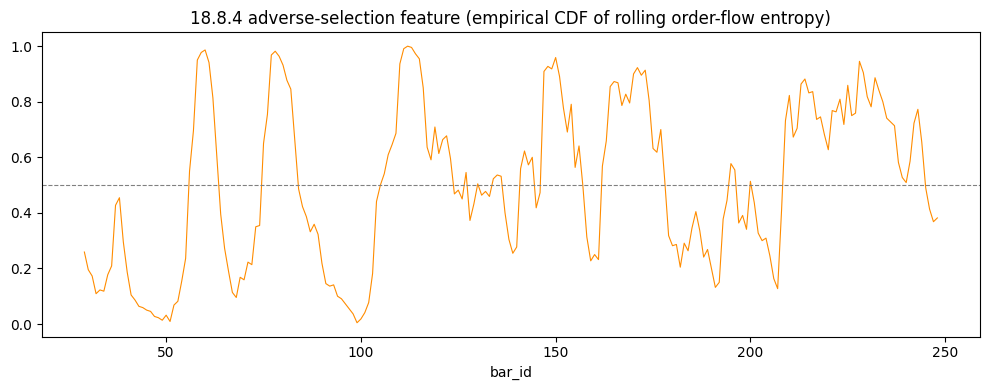

In [6]:
adverse_selection = adverse_selection_feature(
    bars['BuyVolume'].values, bars['SellVolume'].values,
    n_quantiles=5, roll_window=30,
)
print(f"{len(adverse_selection)} real per-bar feature values "
      f"(249 bars, roll_window=30 -> 220 output points)")
print(f"mean={adverse_selection.mean():.4f}, std={adverse_selection.std():.4f}, "
      f"range=[{adverse_selection.min():.4f}, {adverse_selection.max():.4f}]")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(adverse_selection.index, adverse_selection.values, linewidth=0.8, color='darkorange')
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8)
ax.set_title('18.8.4 adverse-selection feature (empirical CDF of rolling order-flow entropy)')
ax.set_xlabel('bar_id')
plt.tight_layout()
plt.show()

**Note:** with only 220 real output points from a 249-bar/~29-day real window, this
feature carries the same "heavy extrapolation from a short real window" caveat this
project has flagged before (Ch13's O-U calibration, Ch15's annualized bet frequency,
Ch17 Part C's BTC explosiveness contrast) -- a real result, just a thinly-supported
one.

## Part C -- 18.8.3 Portfolio Concentration, using Chapter 16's real HRP/IVP weights

Originally scoped as "conceptual only" -- this pipeline is single-asset BTC/TUSD, so no
covariance matrix existed to run 18.8.3 against. Chapter 16 (HRP) later built exactly
that prerequisite: a real 6-commodity covariance matrix, plus two real allocation
vectors (HRP and IVP weights). Per this project's standing "revisit once a later
chapter supplies the prerequisite" rule (2026-08-04), it's implemented now.

**The four steps (book's own notation, Section 18.8.3):**
1. Eigendecompose the covariance matrix: `V W = W Lambda`.
2. Factor loadings: `f_omega = W' omega`.
3. Risk contribution per principal component: `theta_i = [f_omega]_i^2 * Lambda_i,i / sum_n(...)`.
4. Meucci's concentration measure: `H = 1 - (1/N) * exp(-sum(theta_i * log(theta_i)))`.

`H` ranges from 0 (risk spread perfectly evenly across principal components -- maximally
diversified) to `1 - 1/N` (all risk in a single component -- maximally concentrated).


In [ ]:
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch16'))
from chapter_16_hrp import part_b_real_data
from portfolio_concentration import compute_portfolio_concentration

hrp, ivp, corr, ret_df = part_b_real_data()
cov = ret_df.cov()

# Alignment fix (a real bug caught while wiring this up -- verified with a
# synthetic mismatched-order reproduction before touching real data): hrp/ivp
# come back sorted ALPHABETICALLY, but cov keeps the COMMODITIES dict's
# insertion order. Must explicitly reindex before pairing weights with cov's
# rows/columns, or weights silently get paired with the wrong asset.
assets = cov.index.tolist()
hrp_aligned = hrp.reindex(assets)
ivp_aligned = ivp.reindex(assets)
assert not hrp_aligned.isna().any()
assert not ivp_aligned.isna().any()

H_hrp, theta_hrp = compute_portfolio_concentration(cov.values, hrp_aligned.values)
H_ivp, theta_ivp = compute_portfolio_concentration(cov.values, ivp_aligned.values)

theta_hrp_series = pd.Series(theta_hrp, index=assets).sort_values(ascending=False)
theta_ivp_series = pd.Series(theta_ivp, index=assets).sort_values(ascending=False)

n_assets = len(assets)
print(f"HRP portfolio concentration H = {H_hrp:.4f}")
print(f"IVP portfolio concentration H = {H_ivp:.4f}")
print(f"Bounded in [0, {1 - 1/n_assets:.4f}] for N={n_assets} assets\n")
print("Risk contribution (theta), HRP:")
print(theta_hrp_series.to_string())
print("\nRisk contribution (theta), IVP:")
print(theta_ivp_series.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
theta_compare = pd.DataFrame({'HRP': theta_hrp_series, 'IVP': theta_ivp_series})
theta_compare = theta_compare.loc[theta_hrp_series.index]
theta_compare.plot(kind='bar', ax=ax)
ax.set_title('Risk contribution per principal component (theta) -- HRP vs IVP')
ax.set_ylabel('theta_i')
plt.tight_layout()
plt.show()


**Real finding:** HRP is slightly *more* risk-concentrated across principal
components (H=0.2821) than IVP (H=0.2695) -- even though HRP's top-2 *asset-weight*
concentration is slightly *lower* than IVP's (0.756 vs 0.752, Chapter 16's own metric).
These are two different notions of concentration: asset-weight share vs. how risk
distributes across the covariance matrix's principal components.

HRP shifted weight toward the low-vol, low-correlation `gbp` and `tbonds`, but
`crude_oil`/`gold`/`corn` still dominate the portfolio's largest eigenvalue direction --
and HRP's version of that dominance is marginally *more* skewed there (`crude_oil`
theta=0.410 vs IVP's 0.349) than IVP's. This is consistent with Chapter 16's own
finding that HRP and IVP converge for this genuinely low-correlation 6-asset set
(correlations mostly under 0.15 in absolute value): there's little cluster structure
here for HRP's correlation-awareness to actually exploit.


## Conceptual coverage (no pipeline code) -- 18.2, 18.6, 18.7

Per the scope decision with Ethan (2026-08-04): these are real, useful concepts, but
none of them produce a feature this project's single-asset BTC/TUSD pipeline actually
consumes. Flagged as revisitable, not permanently closed -- same status 18.8.3 had
until Chapter 16 supplied its prerequisite (see Part C above).

**18.2 -- Shannon entropy, redundancy, mutual information.** The foundational
definitions this whole chapter builds on (`H[X] = -sum(p[x]*log2(p[x]))`), but they
need KNOWN probabilities -- which is exactly why 18.1-18.4's *estimators* exist. Mutual
information could plausibly become a feature-redundancy diagnostic someday (relevant
given Ch11's "more features made PBO worse" finding), but that's future work, not
implemented here.

**18.6 -- Entropy of a Gaussian process.** Closed form: `H = 0.5*log(2*pi*e*sigma^2)`,
`H ~ 1.42` for a standard Normal. Useful as a benchmark to validate an entropy
estimator against a known answer (the book's own use, Figure 18.1) -- but it's a
validation tool, not a feature a classifier would ever consume.

**18.7 -- Generalized mean / effective number.** `Mq[x,p] = (sum(pi*xi^q))^(1/q)`,
with Shannon's entropy as the special case `q->1`. Pedagogically clarifies *why*
entropy behaves like a diversity measure -- and is the reason 18.8.3's `theta_i`-based
`H` (Part C above) counts as an entropy measure even though `theta_i` isn't literally
a probability. Produces no feature output of its own.
